In [1]:
import os
import time
import logging
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


## Configuration

In [2]:
START_DATE = "2010-01-01"
END_DATE   = datetime.today().strftime("%Y-%m-%d")

# Top N tickers per GICS sector. 30 × 11 sectors = 220-240 tickers
# roughly 4,500-5,000 within-sector candidate pairs for cointegration testing
TICKERS_PER_SECTOR = 30

MAX_MISSING_PCT    = 0.05   # Drop tickers with >5% missing observations
FFILL_LIMIT        = 2      # Forward-fill gaps of at most 2 consecutive days
MIN_HISTORY_DAYS   = 500    # Drop tickers with fewer than 500 trading days

CACHE_DIR          = Path("cache")
PRICES_CACHE       = CACHE_DIR / "prices.parquet"
SECTORS_CACHE      = CACHE_DIR / "sectors.parquet"
CACHE_MAX_AGE_DAYS = 7      # Re-download if cache is older than this

# yfinance download settings
BATCH_SIZE               = 50    # Tickers per batch request
SLEEP_BETWEEN_BATCHES    = 1.0   # Seconds between batches (rate limiting)

print(f"Date range  : {START_DATE} → {END_DATE}")
print(f"Tickers/sector : {TICKERS_PER_SECTOR}")
print(f"Cache location : {CACHE_DIR.resolve()}")

Date range  : 2010-01-01 → 2026-06-12
Tickers/sector : 30
Cache location : C:\Users\kshit\Trading\Pairs Trading\cache


In [3]:
def fetch_sp500_constituents() -> pd.DataFrame:
    """
    Scrape S&P 500 ticker + GICS sector from Wikipedia.

    Returns
    -------
    pd.DataFrame with columns: ticker, sector, sub_industry
    """
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    log.info("Fetching S&P 500 constituent list from Wikipedia...")

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36"
    }

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
    except requests.RequestException as e:
        raise RuntimeError(f"Failed to fetch constituents: {e}")

    soup  = BeautifulSoup(response.text, "html.parser")
    table = soup.find("table", {"id": "constituents"})

    if table is None:
        raise RuntimeError("Could not find constituents table on Wikipedia.")

    rows = []
    for row in table.find_all("tr")[1:]:
        cols = row.find_all("td")
        if len(cols) >= 4:
            ticker       = cols[0].text.strip().replace(".", "-")  # BRK.B → BRK-B
            sector       = cols[2].text.strip()
            sub_industry = cols[3].text.strip()
            rows.append({"ticker": ticker, "sector": sector, "sub_industry": sub_industry})

    df = pd.DataFrame(rows)
    log.info(f"Found {len(df)} constituents across {df['sector'].nunique()} sectors.")
    return df


constituents = fetch_sp500_constituents()
print(f"\nShape: {constituents.shape}")
constituents.head(10)

12:07:40  INFO      Fetching S&P 500 constituent list from Wikipedia...
12:07:42  INFO      Found 503 constituents across 11 sectors.



Shape: (503, 3)


,ticker,sector,sub_industry
0,MMM,Industrials,Industrial Conglomerates
1,AOS,Industrials,Building Products
2,ABT,Health Care,Health Care Equipment
3,ABBV,Health Care,Biotechnology
4,ACN,Information Technology,IT Consulting & Other Services
5,ADBE,Information Technology,Application Software
6,AMD,Information Technology,Semiconductors
7,AES,Utilities,Independent Power Producers & Energy Traders
8,AFL,Financials,Life & Health Insurance
9,A,Health Care,Life Sciences Tools & Services


### Sector distribution across full S&P 500

In [4]:
sector_counts = constituents["sector"].value_counts()
print(sector_counts.to_string())
print(f"\nTotal tickers : {len(constituents)}")
print(f"Total sectors : {constituents['sector'].nunique()}")

sector
Industrials               80
Financials                76
Information Technology    72
Health Care               59
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21

Total tickers : 503
Total sectors : 11


In [5]:
def select_universe(constituents: pd.DataFrame, tickers_per_sector: int = TICKERS_PER_SECTOR) -> pd.DataFrame:
    """
    Select top N tickers per GICS sector.

    Parameters
    ----------
    constituents      : output of fetch_sp500_constituents()
    tickers_per_sector: max tickers to retain per sector

    Returns
    -------
    pd.DataFrame — subset of constituents
    """
    universe = (
        constituents
        .groupby("sector", group_keys=False)
        .head(tickers_per_sector)
        .reset_index(drop=True)
    )
    return universe


universe = select_universe(constituents, TICKERS_PER_SECTOR)

print("Universe selected:")
print(universe.groupby("sector")["ticker"].count().to_string())
print(f"\nTotal tickers in universe : {len(universe)}")
universe.head(10)

Universe selected:
sector
Communication Services    23
Consumer Discretionary    30
Consumer Staples          30
Energy                    21
Financials                30
Health Care               30
Industrials               30
Information Technology    30
Materials                 26
Real Estate               30
Utilities                 30

Total tickers in universe : 310


,ticker,sector,sub_industry
0,MMM,Industrials,Industrial Conglomerates
1,AOS,Industrials,Building Products
2,ABT,Health Care,Health Care Equipment
3,ABBV,Health Care,Biotechnology
4,ACN,Information Technology,IT Consulting & Other Services
5,ADBE,Information Technology,Application Software
6,AMD,Information Technology,Semiconductors
7,AES,Utilities,Independent Power Producers & Energy Traders
8,AFL,Financials,Life & Health Insurance
9,A,Health Care,Life Sciences Tools & Services


### Candidate pair count by sector

This tells us how many cointegration tests we'll run. Formula: n×(n-1)/2 per sector.

In [6]:
from math import comb

pair_counts = (
    universe.groupby("sector")["ticker"]
    .count()
    .rename("tickers")
    .to_frame()
)
pair_counts["candidate_pairs"] = pair_counts["tickers"].apply(lambda n: comb(n, 2))

print(pair_counts.to_string())
print(f"\nTotal candidate pairs to test : {pair_counts['candidate_pairs'].sum():,}")

                        tickers  candidate_pairs
sector                                          
Communication Services       23              253
Consumer Discretionary       30              435
Consumer Staples             30              435
Energy                       21              210
Financials                   30              435
Health Care                  30              435
Industrials                  30              435
Information Technology       30              435
Materials                    26              325
Real Estate                  30              435
Utilities                    30              435

Total candidate pairs to test : 4,268


In [7]:
def download_prices(tickers: list) -> pd.DataFrame:
    """
    Download daily adjusted close prices for all tickers in batches.

    Parameters
    ----------
    tickers : list of ticker symbols

    Returns
    -------
    pd.DataFrame — raw adjusted close, shape (dates, tickers), NaN where missing
    """
    log.info(f"Downloading {len(tickers)} tickers from {START_DATE} to {END_DATE}...")

    all_prices = []
    batches    = [tickers[i:i + BATCH_SIZE] for i in range(0, len(tickers), BATCH_SIZE)]

    for i, batch in enumerate(batches):
        log.info(f"  Batch {i+1}/{len(batches)}  ({len(batch)} tickers)...")
        try:
            raw = yf.download(
                tickers=batch,
                start=START_DATE,
                end=END_DATE,
                auto_adjust=True,
                progress=False,
                threads=True,
            )
            if isinstance(raw.columns, pd.MultiIndex):
                prices_batch = raw["Close"]
            else:
                prices_batch = raw[["Close"]].rename(columns={"Close": batch[0]})

            all_prices.append(prices_batch)

        except Exception as e:
            log.warning(f"  Batch {i+1} failed: {e}. Skipping.")

        time.sleep(SLEEP_BETWEEN_BATCHES)

    if not all_prices:
        raise RuntimeError("All download batches failed.")

    prices = pd.concat(all_prices, axis=1)
    prices.index = pd.to_datetime(prices.index)
    prices.index.name = "date"
    prices = prices.sort_index()

    log.info(f"Download complete: {prices.shape[0]} days × {prices.shape[1]} tickers.")
    return prices


tickers    = universe["ticker"].tolist()
raw_prices = download_prices(tickers)

print(f"\nRaw prices shape : {raw_prices.shape}")
print(f"Date range       : {raw_prices.index[0].date()} → {raw_prices.index[-1].date()}")
print(f"\nSample (last 5 rows, first 8 tickers):")
raw_prices.iloc[-5:, :8]

15:57:39  INFO      Downloading 310 tickers from 2010-01-01 to 2026-06-09...
15:57:39  INFO        Batch 1/7  (50 tickers)...


15:57:58  INFO        Batch 2/7  (50 tickers)...
15:58:10  INFO        Batch 3/7  (50 tickers)...
15:58:19  INFO        Batch 4/7  (50 tickers)...
15:58:32  INFO        Batch 5/7  (50 tickers)...
15:58:41  INFO        Batch 6/7  (50 tickers)...
15:58:52  INFO        Batch 7/7  (10 tickers)...
15:58:57  INFO      Download complete: 4132 days × 310 tickers.



Raw prices shape : (4132, 310)
Date range       : 2010-01-04 → 2026-06-08

Sample (last 5 rows, first 8 tickers):


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE
date,,,,,,,,
2026-06-02,135.050003,315.200012,215.399994,134.350006,86.970001,87.620003,186.220001,262.109985
2026-06-03,137.399994,310.260010,217.130005,133.589996,86.989998,87.889999,177.429993,256.239990
2026-06-04,138.369995,311.230011,224.940002,133.720001,90.779999,88.339996,178.860001,258.420013
2026-06-05,135.440002,307.339996,227.229996,133.539993,91.070000,91.190002,178.250000,251.440002
2026-06-08,132.690002,301.540009,223.070007,134.429993,90.500000,89.610001,174.429993,244.990005


In [8]:
missing_pct = raw_prices.isna().mean().sort_values(ascending=False)

print(f"Tickers with >5% missing  : {(missing_pct > 0.05).sum()}")
print(f"Tickers with >10% missing : {(missing_pct > 0.10).sum()}")
print(f"Tickers with 0% missing   : {(missing_pct == 0).sum()}")
print(f"\nWorst 15 tickers by missing %:")
print((missing_pct.head(15) * 100).round(2).to_string())

Tickers with >5% missing  : 48
Tickers with >10% missing : 41
Tickers with 0% missing   : 259

Worst 15 tickers by missing %:
Ticker
FDXF    99.78
KVUE    81.22
GEHC    78.92
CEG     73.38
APP     68.71
COIN    68.68
EXE     67.64
ABNB    66.65
DASH    66.63
CARR    62.17
DDOG    59.15
CRWD    57.48
CTVA    57.19
DOW     56.07
FOX     55.95


In [9]:
def clean_prices(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Clean raw price data: drop bad tickers, fill short gaps, align calendar.

    Parameters
    ----------
    prices : raw adjusted close from download_prices()

    Returns
    -------
    pd.DataFrame — cleaned prices, same structure
    """
    log.info("Cleaning price data...")
    n0 = prices.shape[1]

    # 1 — Drop tickers with too many NaNs
    missing_pct = prices.isna().mean()
    prices = prices.loc[:, missing_pct <= MAX_MISSING_PCT]
    log.info(f"  After missing data filter  : {prices.shape[1]} tickers (dropped {n0 - prices.shape[1]})")

    # 2 — Forward-fill short gaps
    prices = prices.ffill(limit=FFILL_LIMIT)

    # 3 — Drop rows where every ticker is NaN (non-trading days that slipped through)
    prices = prices.dropna(how="all")

    # 4 — Drop tickers with too little history
    n1 = prices.shape[1]
    history_len = prices.notna().sum()
    prices = prices.loc[:, history_len >= MIN_HISTORY_DAYS]
    log.info(f"  After history length filter : {prices.shape[1]} tickers (dropped {n1 - prices.shape[1]})")

    # 5 — Drop tickers that started after 2011-01-01
    n2 = prices.shape[1]
    cutoff     = pd.Timestamp("2011-01-01")
    first_valid = prices.apply(lambda col: col.first_valid_index())
    prices = prices.loc[:, first_valid <= cutoff]
    log.info(f"  After start-date filter     : {prices.shape[1]} tickers (dropped {n2 - prices.shape[1]})")

    # Final — drop any residual columns with too many NaNs post-ffill
    prices = prices.dropna(axis=1, thresh=int(len(prices) * (1 - MAX_MISSING_PCT)))

    log.info(f"Cleaning complete. Final shape: {prices.shape}")
    return prices


prices = clean_prices(raw_prices)

print(f"\nBefore cleaning : {raw_prices.shape[1]} tickers")
print(f"After cleaning  : {prices.shape[1]} tickers")
print(f"Trading days    : {prices.shape[0]}")
print(f"Remaining NaNs  : {prices.isna().sum().sum()}")
prices.tail(5)

15:59:26  INFO      Cleaning price data...
15:59:27  INFO        After missing data filter  : 262 tickers (dropped 48)


15:59:27  INFO        After history length filter : 262 tickers (dropped 0)
15:59:27  INFO        After start-date filter     : 262 tickers (dropped 0)
15:59:27  INFO      Cleaning complete. Final shape: (4132, 262)



Before cleaning : 310 tickers
After cleaning  : 262 tickers
Trading days    : 4132
Remaining NaNs  : 192


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,AEE,AEP,...,UDR,VLO,DIS,VMC,VTR,VZ,WBD,WEC,WELL,WMB
date,,,,,,,,,,,,,,,,,,,,,
2026-06-02,135.050003,315.200012,86.970001,87.620003,186.220001,262.109985,423.200012,82.459999,106.779999,127.110001,...,36.840000,258.260010,101.410004,281.839996,80.129997,47.869999,27.180000,110.230003,195.350006,71.309998
2026-06-03,137.399994,310.260010,86.989998,87.889999,177.429993,256.239990,437.670013,84.110001,106.230003,126.309998,...,37.610001,261.450012,99.389999,285.299988,79.040001,46.650002,27.000000,110.050003,199.589996,71.660004
2026-06-04,138.369995,311.230011,90.779999,88.339996,178.860001,258.420013,428.760010,83.370003,106.989998,127.790001,...,38.900002,258.850006,99.339996,283.059998,79.099998,44.869999,27.000000,111.230003,200.850006,72.430000
2026-06-05,135.440002,307.339996,91.070000,91.190002,178.250000,251.440002,401.390015,80.919998,109.269997,129.139999,...,39.200001,255.820007,99.709999,281.380005,82.019997,45.369999,26.240000,112.949997,206.929993,71.959999
2026-06-08,132.690002,301.540009,90.500000,89.610001,174.429993,244.990005,403.890015,80.220001,107.150002,126.769997,...,38.610001,258.390015,98.870003,269.980011,79.620003,45.439999,26.469999,111.250000,200.000000,71.589996


In [10]:
sector_map     = universe.set_index("ticker")["sector"]
sub_ind_map    = universe.set_index("ticker")["sub_industry"]
sectors        = sector_map.reindex(prices.columns).dropna()
sub_industries = sub_ind_map.reindex(sectors.index)
prices         = prices[sectors.index]

print("Final sector breakdown:")
print(sectors.value_counts().to_string())
print(f"\nTotal tickers with sector labels : {len(sectors)}")
print(f"Prices shape (aligned)           : {prices.shape}")

Final sector breakdown:
sector
Consumer Staples          28
Utilities                 28
Real Estate               28
Health Care               27
Industrials               26
Financials                24
Consumer Discretionary    24
Materials                 23
Information Technology    22
Communication Services    17
Energy                    15

Total tickers with sector labels : 262
Prices shape (aligned)           : (4132, 262)


## Cache to Parquet

Saves both objects to `cache/` so every subsequent notebook loads instantly.
The cache is considered fresh for 7 days — after that `load_universe()` re-downloads.


In [11]:
def save_cache(prices: pd.DataFrame, sectors: pd.Series, sub_industries: pd.Series) -> None:
    """Save prices and sectors to parquet."""
    CACHE_DIR.mkdir(exist_ok=True)
    prices.to_parquet(PRICES_CACHE)
    pd.DataFrame({"sector": sectors, "sub_industry": sub_industries}).to_parquet(SECTORS_CACHE)
    log.info(f"Saved to {CACHE_DIR}/")
    print(f"prices.parquet  : {PRICES_CACHE.stat().st_size / 1e6:.1f} MB")
    print(f"sectors.parquet : {SECTORS_CACHE.stat().st_size / 1e3:.1f} KB")


def load_cache() -> tuple:
    """Load prices and sectors from parquet cache."""
    prices  = pd.read_parquet(PRICES_CACHE)
    sectors = pd.read_parquet(SECTORS_CACHE)["sector"]
    log.info(f"Loaded from cache: {prices.shape[0]} days, {prices.shape[1]} tickers.")
    return prices, sectors


def _cache_is_fresh() -> bool:
    """True if cache exists and is under CACHE_MAX_AGE_DAYS old."""
    if not PRICES_CACHE.exists() or not SECTORS_CACHE.exists():
        return False
    age_days = (time.time() - PRICES_CACHE.stat().st_mtime) / 86400
    return age_days < CACHE_MAX_AGE_DAYS


save_cache(prices, sectors, sub_industries)
print("\nCache saved successfully.")

15:59:41  INFO      Saved to cache/


prices.parquet  : 7.6 MB
sectors.parquet : 6.6 KB

Cache saved successfully.


## `load_universe()` — The Single Entry Point

Every downstream notebook calls exactly this one function.
It handles cache logic transparently.


In [12]:
def load_universe(force_refresh: bool = False, tickers_per_sector: int = TICKERS_PER_SECTOR) -> tuple:
    """
    Load prices and sector labels for the full universe.

    Parameters
    ----------
    force_refresh     : if True, ignore cache and re-download
    tickers_per_sector: tickers to retain per GICS sector

    Returns
    -------
    prices  : pd.DataFrame  shape (trading_days, n_tickers), adjusted close
    sectors : pd.Series     index=ticker, values=GICS sector string

    Example
    -------
    >>> prices, sectors = load_universe()
    >>> prices.shape
    (3500, 218)
    >>> sectors["AAPL"]
    'Information Technology'
    """
    if not force_refresh and _cache_is_fresh():
        log.info("Cache is fresh — loading from disk.")
        return load_cache()

    log.info("Cache missing or stale — running full pipeline.")
    constituents = fetch_sp500_constituents()
    universe_df  = select_universe(constituents, tickers_per_sector)
    tickers_list = universe_df["ticker"].tolist()
    raw          = download_prices(tickers_list)
    clean        = clean_prices(raw)
    sec_map      = universe_df.set_index("ticker")["sector"]
    sub_ind_map  = universe_df.set_index("ticker")["sub_industry"]
    secs         = sec_map.reindex(clean.columns).dropna()
    sub_inds     = sub_ind_map.reindex(secs.index)
    clean        = clean[secs.index]
    save_cache(clean, secs, sub_inds)
    return clean, secs


# ── Test: load from cache (should be instant) ────────────────────────────────
prices, sectors = load_universe(force_refresh=False)
print(f"prices shape : {prices.shape}")
print(f"sectors      : {len(sectors)} tickers")

15:59:55  INFO      Cache is fresh — loading from disk.
15:59:56  INFO      Loaded from cache: 4132 days, 262 tickers.


prices shape : (4132, 262)
sectors      : 262 tickers


In [6]:
#Fetch & cache S&P 500 index (^GSPC)
_sp500_cache = CACHE_DIR / "sp500.parquet"

_sp = yf.download("^GSPC", start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

if isinstance(_sp.columns, pd.MultiIndex):
    _sp = _sp["Close"]["^GSPC"]
else:
    _sp = _sp["Close"]

_sp = _sp.dropna()
_sp.index = pd.to_datetime(_sp.index)
_sp.name  = "sp500"
_sp.to_frame().to_parquet(_sp500_cache)
print(f"S&P 500 saved  : {_sp500_cache}  ({len(_sp)} rows, "
      f"{_sp.index[0].date()} → {_sp.index[-1].date()})")


S&P 500 saved  : cache\sp500.parquet  (4135 rows, 2010-01-04 → 2026-06-11)


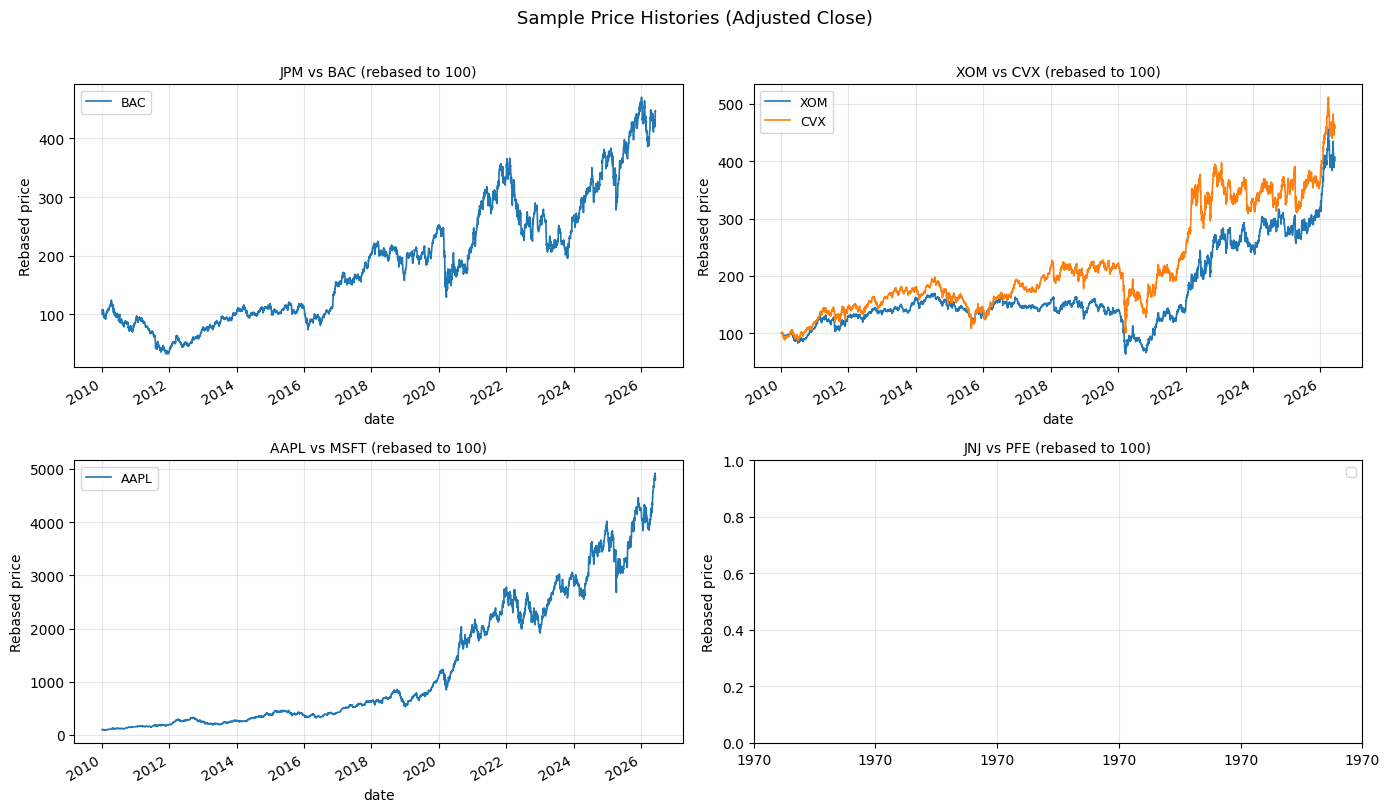

Plot saved to cache/sample_price_histories.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Sample Price Histories (Adjusted Close)", fontsize=13, y=1.01)

sample_pairs = [("JPM", "BAC"), ("XOM", "CVX"), ("AAPL", "MSFT"), ("JNJ", "PFE")]

for ax, (t1, t2) in zip(axes.flat, sample_pairs):
    for t in [t1, t2]:
        if t in prices.columns:
            (prices[t] / prices[t].iloc[0] * 100).plot(ax=ax, label=t, linewidth=1.2)
    ax.set_title(f"{t1} vs {t2} (rebased to 100)", fontsize=10)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_ylabel("Rebased price")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cache/sample_price_histories.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot saved to cache/sample_price_histories.png")